## Morphological operators to perform image manipulation and filtering
__Author__: Masa Prodanovic
__Last update__: Aug 2024

Morphological image processing is a collection of non-linear operations related to the shape or morphology of features in an image, such as boundaries, skeletons, etc. In any given technique, we probe an image with a small shape or template called a structuring element, which defines the region of interest or neighborhood around a pixel. We have introduced that in the previous lecture on grayscale image filtering.

For the most part, we will focus on morphological processing binary (segmented images) as it is very useful in creating input for further simulation in digital rock physics. However all of the operations exemplified here are work for any type of __binary or grayscale__ image but __not color__ images (i.e. cannot use them directly on images with 3 or 4 channels).

__References__:
1. This lecture was created based on scikit implementation of the morphological operations shown here:
https://scikit-image.org/docs/dev/auto_examples/applications/plot_morphology.html#sphx-glr-auto-examples-applications-plot-morphology-py

2. Textbook on the morphological image processing is:
P.Soille, Morphological Image Analysis: Principles and Applications 2nd Edition, Springer, 2002.

3. [MathWorks tutorial on morphological processing](https://se.mathworks.com/help/images/morphological-dilation-and-erosion.html)

__The implementation in scikit is different from ImageJ (to my knowledge, ImageJ works only with binarized images), so note the definitions stated below__


## Morphological Filtering

Morphological image processing is a collection of non-linear operations related
to the shape or morphology of features in an image, such as boundaries,
skeletons, etc. In any given technique, we probe an image with a small shape or
template called a structuring element, which defines the region of interest or
neighborhood around a pixel.

We outline the following basic morphological operations:

1. Erosion
2. Dilation
3. Opening
4. Closing
5. White Tophat
6. Black Tophat
7. Medial axis and skeletonization

## Import skimage tools and read in an example image
To get started, let's import all of the needed tools and load an image using ``io.imread``.
Note that morphology functions only work on gray-scale or binary images; if reading in color images convert them during readin using option ``as_gray=True``.

We are first going to use a simple binary image with disks.

In [3]:
# import tools

import skimage.io as io

from skimage.morphology import erosion, dilation, opening, closing
from skimage.morphology import white_tophat, black_tophat, medial_axis, skeletonize
from skimage.morphology import disk

import matplotlib.pyplot as plt

# read image
folder = "..\Lecture3_4_5_Data\Filtering_Segmentation\DataBeads3D"
file  = "beads_dry.slice150.sub.binary.png"
filename = folder+"\\"+file

img = io.imread(filename)

<>:12: SyntaxWarning: invalid escape sequence '\L'
<>:12: SyntaxWarning: invalid escape sequence '\L'
C:\Users\masha\AppData\Local\Temp\ipykernel_41112\2534182203.py:12: SyntaxWarning: invalid escape sequence '\L'
  folder = "..\Lecture3_4_5_Data\Filtering_Segmentation\DataBeads3D"


Let's also define a convenience function for plotting comparisons:



In [4]:
def plot_comparison(original, filtered, filter_name):

    fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(8, 4), sharex=True,
                                   sharey=True)
    ax1.imshow(original, cmap=plt.cm.gray)
    ax1.set_title('original')
    ax1.axis('off')
    ax2.imshow(filtered, cmap=plt.cm.gray)
    ax2.set_title(filter_name)
    ax2.axis('off')

## Erosion

Morphological ``erosion`` sets a pixel at (i, j) to the __minimum over all
pixels in the neighborhood centered at (i, j)__. The structuring element,
``footprint``, passed to ``erosion`` is a boolean array that describes this
neighborhood. Below, we use ``disk`` to create a circular structuring
element, which we use for most of the following examples.



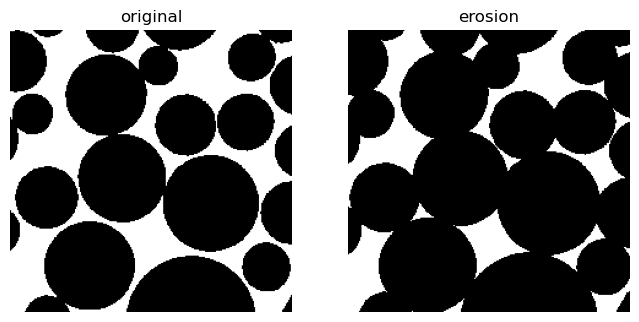

In [5]:
footprint = disk(3)
eroded = erosion(img, footprint)
plot_comparison(img, eroded, 'erosion')

Play with size of the disk and notice how the white boundary of the image disappears or gets eroded (and the black phase dilated! as we increase the size of the disk.

## Dilation

Morphological ``dilation`` sets a pixel at (i, j) to the __maximum over all
pixels in the neighborhood centered at (i, j)__. Dilation enlarges bright
regions and shrinks dark regions.



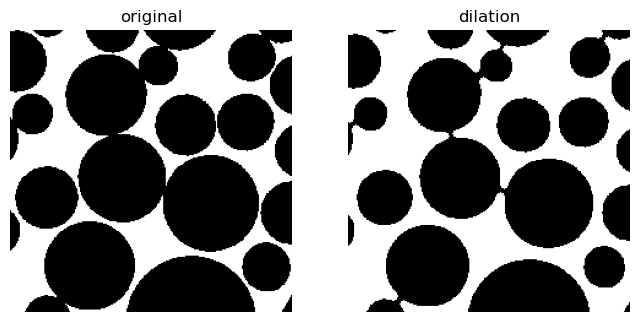

In [6]:
dilated = dilation(img, footprint)
plot_comparison(img, dilated, 'dilation')

Notice how the white boundary of the image thickens, or gets dilated, as we
increase the size of the disk (footprint).

## Opening

Morphological ``opening`` on an image is defined as an *erosion followed by
a dilation*. Opening can remove small bright spots (i.e. "salt") and
connect small dark cracks.



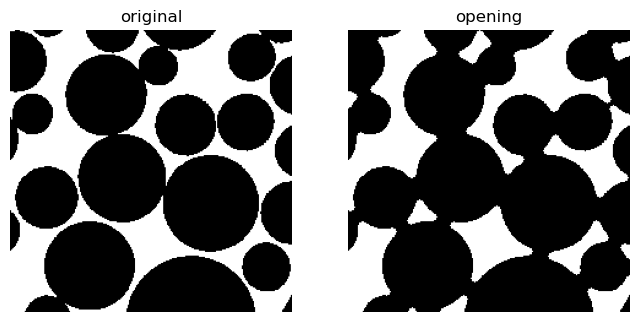

In [7]:
opened = opening(img, footprint)
plot_comparison(img, opened, 'opening')

Since ``opening`` an image starts with an erosion operation, light regions
that are *smaller* than the structuring element are removed. The dilation
operation that follows ensures that light regions that are *larger* than
the structuring element retain their original size.

## Closing

Morphological ``closing`` on an image is defined as a *dilation followed by
an erosion*. Closing can remove small dark spots (i.e. "pepper") and
connect small bright cracks.





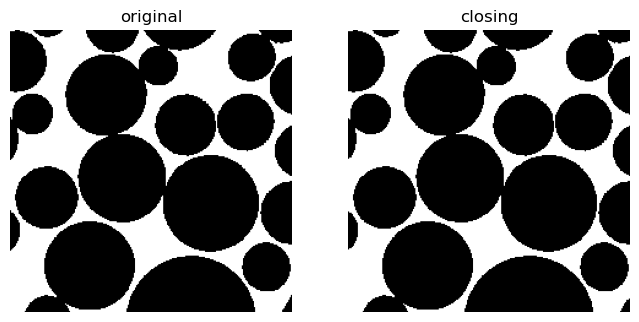

In [8]:
closed = closing(img, footprint)
plot_comparison(img, closed, 'closing')

Since ``closing`` an image starts with an dilation operation, dark regions
that are *smaller* than the structuring element are removed. The dilation
operation that follows ensures that dark regions that are *larger* than the
structuring element retain their original size. 

## White tophat

The ``white_tophat`` of an image is defined as the *image minus its
morphological opening*. This operation returns the bright spots of the
image that are smaller than the structuring element.




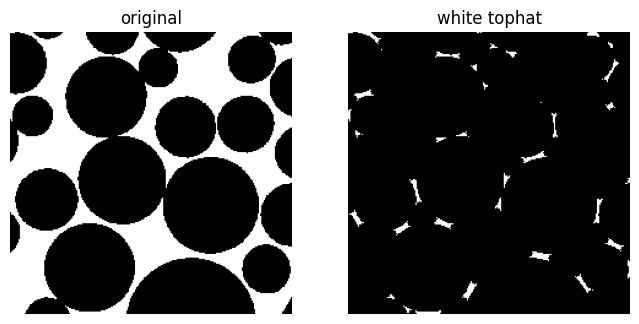

In [12]:
w_tophat = white_tophat(img, footprint)
plot_comparison(img, w_tophat, 'white tophat')


## Black tophat

The ``black_tophat`` of an image is defined as its morphological **closing
minus the original image**. This operation returns the *dark spots of the
image that are smaller than the structuring element*.



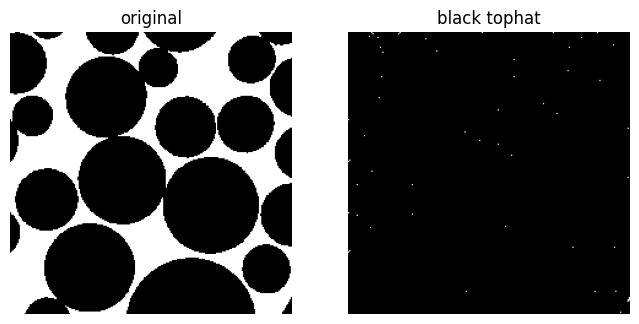

In [13]:
b_tophat = black_tophat(img, footprint)
plot_comparison(img, b_tophat, 'black tophat')



**Duality**

As you should have noticed, many of these operations are simply the reverse
of another operation. This duality can be summarized as follows:

  1. Erosion <-> Dilation

  2. Opening <-> Closing

  3. White tophat <-> Black tophat

## Medial axis: introductory example

Thinning is used to reduce each connected component in a binary image to a
*single-pixel wide skeleton*. It is important to note that this is
performed on binary images only.



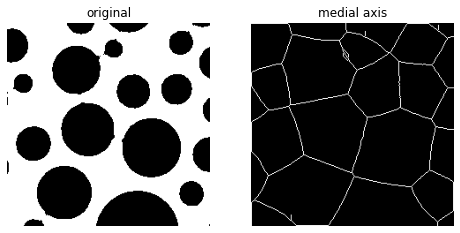

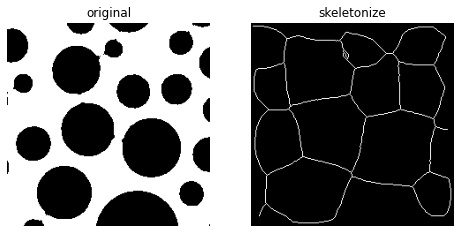

In [17]:
ma = medial_axis(dilated == 255)
plot_comparison(dilated, ma, 'medial axis')


sk = skeletonize(dilated == 255,method='lee')
plot_comparison(dilated, sk, 'skeletonize')


## Example use of morphological operators on grayscale images

This example is verbatim scikit documentation. The image is that of a retina, and it has structures that are small in one direction but not in all directions, and it has two structures that are small and circular (small in all directions). 

The diamater of interest to detect is set to 10. 

Morphological closing will remove ALL structures that are smaller than the diamater at least in one direction.

Diameter closing will remove only circular ones (and leave thin elongated arteries alone).

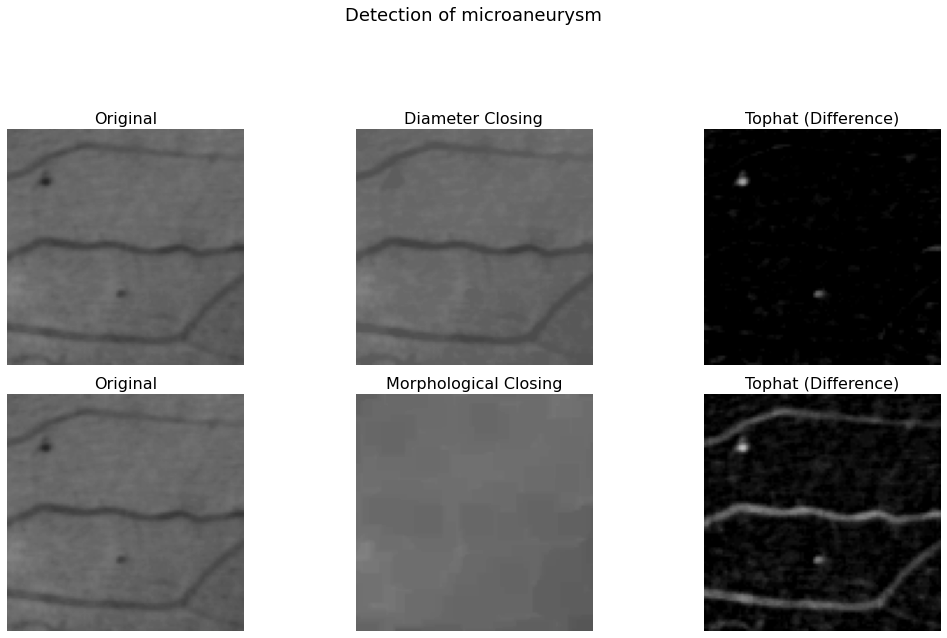

In [30]:
import numpy as np
import matplotlib.pyplot as plt
from skimage.morphology import diameter_closing
from skimage import data
from skimage.morphology import closing
from skimage.morphology import square

datasets = {
    'retina': {'image': data.microaneurysms(),
               'figsize': (15, 9),
               'diameter': 10,
               'vis_factor': 3,
               'title': 'Detection of microaneurysm'}
}

for dataset in datasets.values():
    # image with printed letters
    image = dataset['image']
    figsize = dataset['figsize']
    diameter = dataset['diameter']

    fig, ax = plt.subplots(2, 3, figsize=figsize)
    # Original image
    ax[0, 0].imshow(image, cmap='gray', aspect='equal',
                    vmin=0, vmax=255)
    ax[0, 0].set_title('Original', fontsize=16)
    ax[0, 0].axis('off')

    ax[1, 0].imshow(image, cmap='gray', aspect='equal',
                    vmin=0, vmax=255)
    ax[1, 0].set_title('Original', fontsize=16)
    ax[1, 0].axis('off')

    # Diameter closing : we remove all dark structures with a maximal
    # extension of less than <diameter> defined above. I.e. in closed_attr, all
    # local minima have at least a maximal extension of <diameter>.
    closed_attr = diameter_closing(image, diameter, connectivity=2)

    # We then calculate the difference to the original image.
    tophat_attr = closed_attr - image

    ax[0, 1].imshow(closed_attr, cmap='gray', aspect='equal',
                    vmin=0, vmax=255)
    ax[0, 1].set_title('Diameter Closing', fontsize=16)
    ax[0, 1].axis('off')

    ax[0, 2].imshow(dataset['vis_factor'] * tophat_attr, cmap='gray',
                    aspect='equal', vmin=0, vmax=255)
    ax[0, 2].set_title('Tophat (Difference)', fontsize=16)
    ax[0, 2].axis('off')

    # A morphological closing removes all dark structures that cannot
    # contain a structuring element of a certain size.
    closed = closing(image, square(diameter))

    # Again we calculate the difference to the original image.
    tophat = closed - image

    ax[1, 1].imshow(closed, cmap='gray', aspect='equal',
                    vmin=0, vmax=255)
    ax[1, 1].set_title('Morphological Closing', fontsize=16)
    ax[1, 1].axis('off')

    ax[1, 2].imshow(dataset['vis_factor'] * tophat, cmap='gray',
                    aspect='equal', vmin=0, vmax=255)
    ax[1, 2].set_title('Tophat (Difference)', fontsize=16)
    ax[1, 2].axis('off')
    fig.suptitle(dataset['title'], fontsize=18)
    fig.tight_layout(rect=(0, 0, 1, 0.88))

plt.show()